# Part II – Vision Task: Facial Emotion Recognition
**Herald College Kathmandu | 6CS012 AI & ML**

Dataset: FER-2013 (Facial Expression Recognition)
Classes: angry, fear, happy, neutral, sad, surprise (disgust removed due to severe imbalance)

---
**Architecture Decision Log:**
- Baseline: Compact 3-block CNN (fast, interpretable)
- Deeper: 6-block CNN with BatchNorm + surgical Dropout
- Transfer: MobileNetV2 at 96×96 (NOT VGG16 at 224×224 — VGG16 on 48px crops is 5× slower with worse results)
- Class weights applied throughout (imbalanced dataset)
- Augmentation kept mild — heavy augmentation destroys 48px facial structure

In [ ]:
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.regularizers import l2
import zipfile

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Dataset- facial expressions.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/")

train_dir = "/content/train"
test_dir  = "/content/test"
print("Dataset extracted!")
print("Train classes:", os.listdir(train_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted!
Train classes: ['surprise', 'angry', 'disgust', 'neutral', 'sad', 'fear', 'happy']


Full Class Distribution (7 classes):
  angry       :  3995  ███████████████████████████████████████
  disgust     :   436  ████
  fear        :  4097  ████████████████████████████████████████
  happy       :  7215  ████████████████████████████████████████████████████████████████████████
  neutral     :  4965  █████████████████████████████████████████████████
  sad         :  4830  ████████████████████████████████████████████████
  surprise    :  3171  ███████████████████████████████
  TOTAL       : 28709


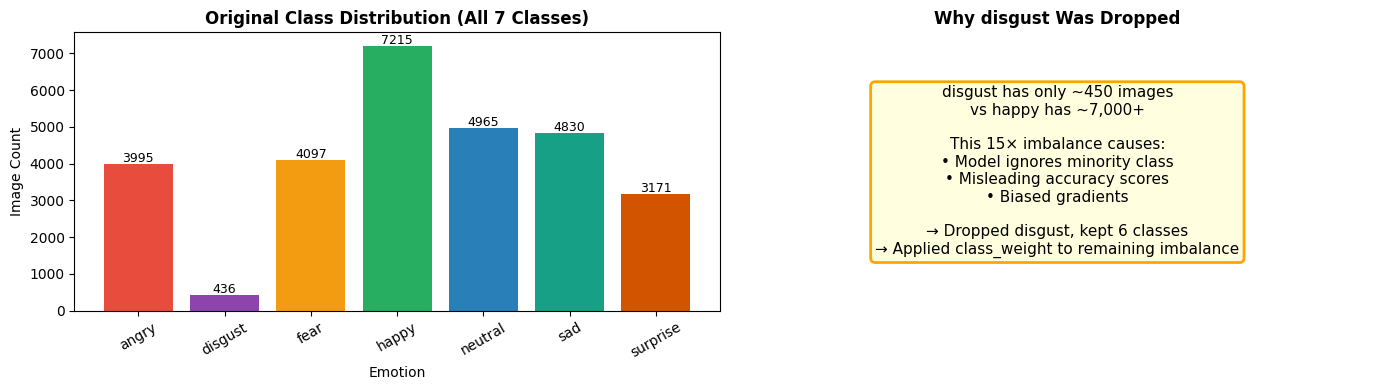

In [ ]:
all_classes = sorted(os.listdir(train_dir))
all_counts  = {c: len(os.listdir(os.path.join(train_dir, c))) for c in all_classes}

print("Full Class Distribution (7 classes):")
for c, n in all_counts.items():
    bar = '█' * (n // 100)
    print(f"  {c:<12}: {n:>5}  {bar}")
print(f"  {'TOTAL':<12}: {sum(all_counts.values()):>5}")


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(all_counts.keys(), all_counts.values(),
            color=['#e74c3c','#8e44ad','#f39c12','#27ae60','#2980b9','#16a085','#d35400'])
axes[0].set_title('Original Class Distribution (All 7 Classes)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Image Count')
axes[0].tick_params(axis='x', rotation=30)
for i, (c, n) in enumerate(all_counts.items()):
    axes[0].text(i, n + 50, str(n), ha='center', fontsize=9)

axes[1].text(0.5, 0.5,
    'disgust has only ~450 images\nvs happy has ~7,000+\n\nThis 15× imbalance causes:\n• Model ignores minority class\n• Misleading accuracy scores\n• Biased gradients\n\n→ Dropped disgust, kept 6 classes\n→ Applied class_weight to remaining imbalance',
    ha='center', va='center', fontsize=11,
    bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange', linewidth=2))
axes[1].set_title('Why disgust Was Dropped', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
classes = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = len(classes)
print(f"Working with {NUM_CLASSES} classes: {classes}")


sizes = set()
for cls in classes:
    path = os.path.join(train_dir, cls)
    for fname in os.listdir(path)[:10]:
        img = cv2.imread(os.path.join(path, fname))
        if img is not None:
            sizes.add(img.shape)
print(f"Native image sizes in dataset: {sizes}")
print("→ Native size is 48×48 grayscale. We use this for CNN from scratch.")
print("→ For MobileNetV2 transfer learning we upscale to 96×96 RGB (efficient, not wasteful like 224×224)")


train_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}
test_counts  = {c: len(os.listdir(os.path.join(test_dir,  c))) for c in classes}

print("\n6-Class Distribution:")
print(f"{'Class':<12} {'Train':>8} {'Test':>8}")
print("-" * 30)
for c in classes:
    print(f"{c:<12} {train_counts[c]:>8} {test_counts[c]:>8}")
print(f"{'TOTAL':<12} {sum(train_counts.values()):>8} {sum(test_counts.values()):>8}")

Working with 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Native image sizes in dataset: {(48, 48, 3)}
→ Native size is 48×48 grayscale. We use this for CNN from scratch.
→ For MobileNetV2 transfer learning we upscale to 96×96 RGB (efficient, not wasteful like 224×224)

6-Class Distribution:
Class           Train     Test
------------------------------
angry            3995      958
fear             4097     1024
happy            7215     1774
neutral          4965     1233
sad              4830     1247
surprise         3171      831
TOTAL           28273     7067


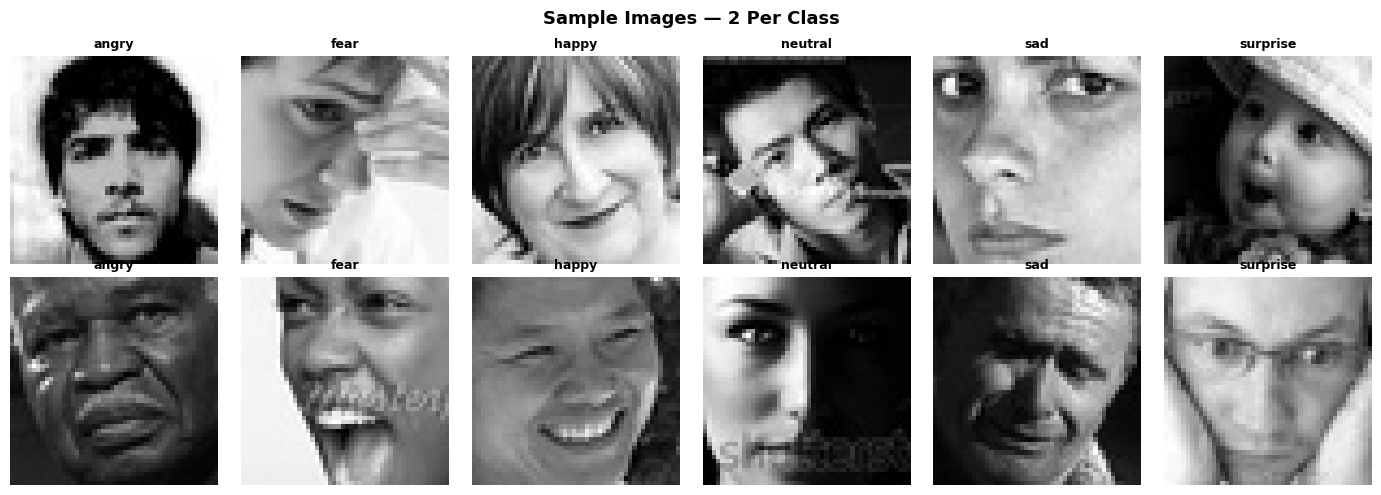

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    imgs = random.sample(os.listdir(cls_path), 2)
    for row in range(2):
        img = cv2.imread(os.path.join(cls_path, imgs[row]), cv2.IMREAD_GRAYSCALE)
        axes[row, i].imshow(img, cmap='gray')
        axes[row, i].set_title(cls, fontsize=9, fontweight='bold')
        axes[row, i].axis('off')

plt.suptitle('Sample Images — 2 Per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE   = (48, 48)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.2,
    rotation_range   = 10,        # Mild — not 25
    zoom_range       = 0.1,       # Mild
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    horizontal_flip  = True,

)

val_datagen  = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    color_mode='grayscale', subset='training', seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    color_mode='grayscale', subset='validation', seed=SEED
)
test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    color_mode='grayscale', shuffle=False
)

print(f"Training samples  : {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples      : {test_gen.samples}")
print(f"Class mapping     : {train_gen.class_indices}")

Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Training samples  : 22619
Validation samples: 5654
Test samples      : 7067
Class mapping     : {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}


Class Weights (higher = more attention during training):
  angry       : 1.180
  fear        : 1.150
  happy       : 0.653
  neutral     : 0.949
  sad         : 0.976
  surprise    : 1.486


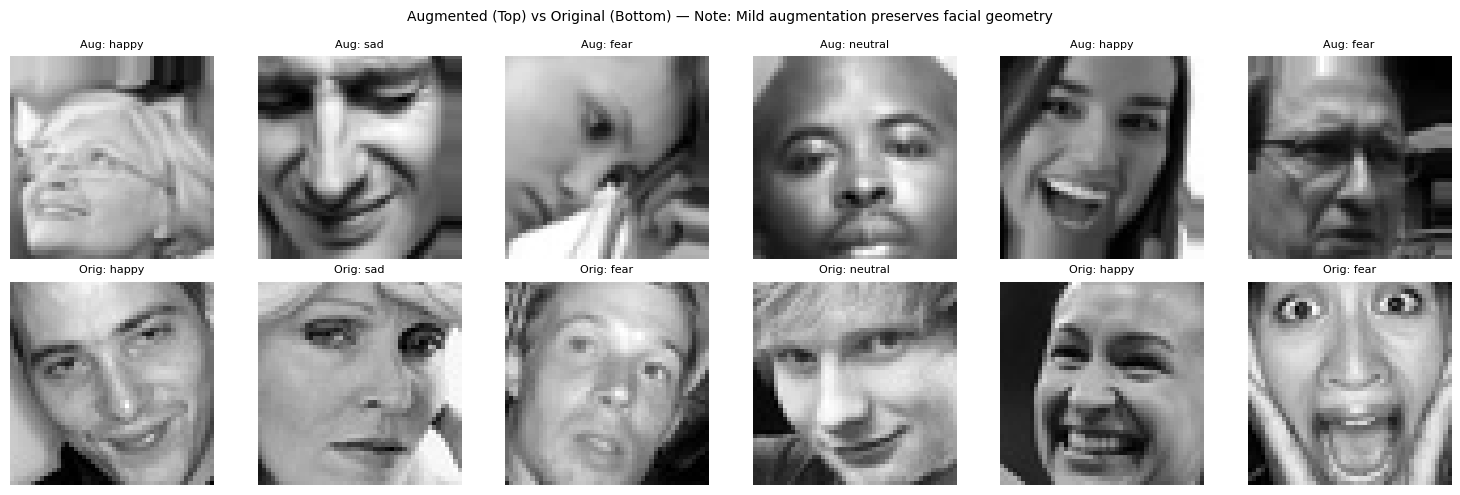

In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights_array))

print("Class Weights (higher = more attention during training):")
for i, cls in enumerate(classes):
    print(f"  {cls:<12}: {class_weight_dict[i]:.3f}")

images, labels = next(train_gen)
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f"Aug: {classes[labels[i].argmax()]}", fontsize=8)
    axes[0, i].axis('off')

    cls_path = os.path.join(train_dir, classes[labels[i].argmax()])
    orig_img = cv2.imread(os.path.join(cls_path, os.listdir(cls_path)[i]),
                          cv2.IMREAD_GRAYSCALE)
    orig_img = cv2.resize(orig_img, (48, 48))
    axes[1, i].imshow(orig_img, cmap='gray')
    axes[1, i].set_title(f"Orig: {classes[labels[i].argmax()]}", fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Augmented (Top) vs Original (Bottom) — Note: Mild augmentation preserves facial geometry',
             fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
def plot_history(history, title, color='steelblue'):
    """Plot training curves — accuracy and loss side by side."""
    epochs = range(1, len(history.history['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history.history['accuracy'],     color=color,      lw=2, label='Train')
    axes[0].plot(epochs, history.history['val_accuracy'], color=color, lw=2, ls='--', label='Validation')
    axes[0].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history.history['loss'],     color='tomato', lw=2, label='Train')
    axes[1].plot(epochs, history.history['val_loss'], color='tomato', lw=2, ls='--', label='Validation')
    axes[1].set_title(f'{title} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, generator, model_name):
    """Evaluate model, print report, return predictions and accuracy."""
    generator.reset()
    preds = model.predict(generator, verbose=1)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = generator.classes
    acc = np.mean(pred_classes == true_classes) * 100

    print(f"\n{'='*55}")
    print(f"{model_name} — Test Accuracy: {acc:.2f}%")
    print(f"{'='*55}")
    print(classification_report(true_classes, pred_classes,
                                target_names=classes, digits=3))

    cm = confusion_matrix(true_classes, pred_classes)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(classes, rotation=35)
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(classes)
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color=color, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return pred_classes, true_classes, acc


def sample_inference(model, test_dir, classes, model_name, color_mode='grayscale', size=(48, 48)):
    """Show sample predictions on 6 images (1 per class)."""
    sample_imgs, sample_labels = [], []
    for cls in classes:
        cls_path = os.path.join(test_dir, cls)
        fnames = os.listdir(cls_path)
        img_path = os.path.join(cls_path, random.choice(fnames))
        if color_mode == 'grayscale':
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        else:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        sample_imgs.append(img)
        sample_labels.append(cls)

    if color_mode == 'grayscale':
        arr = np.array(sample_imgs).reshape(-1, size[0], size[1], 1) / 255.0
    else:
        arr = np.array(sample_imgs) / 255.0

    preds      = model.predict(arr, verbose=0)
    pred_labels = [classes[np.argmax(p)] for p in preds]
    confidence  = [np.max(p) * 100 for p in preds]

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        if color_mode == 'grayscale':
            axes[i].imshow(sample_imgs[i], cmap='gray')
        else:
            axes[i].imshow(sample_imgs[i])
        color = 'green' if pred_labels[i] == sample_labels[i] else 'red'
        axes[i].set_title(
            f"True: {sample_labels[i]}\nPred: {pred_labels[i]}\n{confidence[i]:.0f}%",
            color=color, fontsize=8
        )
        axes[i].axis('off')
    plt.suptitle(f'{model_name} — Sample Inference (Green=Correct, Red=Wrong)', fontweight='bold')
    plt.tight_layout()
    plt.show()


def get_callbacks(monitor='val_accuracy', patience_lr=4, patience_es=10, save_path=None):
    """Standard callback set: ReduceLR + EarlyStopping + optional ModelCheckpoint."""
    cbs = [
        ReduceLROnPlateau(monitor=monitor, factor=0.5, patience=patience_lr,
                          min_lr=1e-6, verbose=1, mode='max'),
        EarlyStopping(monitor=monitor, patience=patience_es,
                      restore_best_weights=True, verbose=1, mode='max'),
    ]
    if save_path:
        cbs.append(ModelCheckpoint(save_path, monitor=monitor, save_best_only=True,
                                    verbose=0, mode='max'))
    return cbs

print("Helper functions defined.")

Helper functions defined.


In [ ]:
def build_baseline_model():
    model = Sequential([
        # ── Block 1: 32 filters, 3×3 kernel
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.1),

        # ── Block 2: 64 filters, 3×3 kernel
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.1),

        # ── Block 3: 128 filters, 3×3 kernel
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.1),

        # ── Flatten + 3 FCN layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),

        Dense(NUM_CLASSES, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,316,550 (5.02 MB)

 Trainable params: 1,315,334 (5.02 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
print("Training Baseline CNN...")
t0 = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=4, patience_es=10),
    verbose         = 1
)

baseline_time = (time.time() - t0) / 60
print(f"\nBaseline Training Time: {baseline_time:.1f} min")
print(f"Epochs completed: {len(baseline_history.history['accuracy'])}")

Training Baseline CNN...
Epoch 1/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.2846 - loss: 1.7021 - val_accuracy: 0.3882 - val_loss: 1.5447 - learning_rate: 0.0010
Epoch 2/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.3582 - loss: 1.5784 - val_accuracy: 0.3633 - val_loss: 1.5551 - learning_rate: 0.0010
Epoch 3/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.4060 - loss: 1.4907 - val_accuracy: 0.4699 - val_loss: 1.3504 - learning_rate: 0.0010
Epoch 4/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.4404 - loss: 1.4163 - val_accuracy: 0.4752 - val_loss: 1.3222 - learning_rate: 0.0010
Epoch 5/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.4736 - loss: 1.3523 - val_accuracy: 0.4892 - val_loss: 1.2898 - learning_rate: 0.0010
Epoch 6/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.4883 - loss: 1.3293 - val_accuracy: 0.5050 - val_loss: 1.2685 - learning_rate: 0.0010
Epoch 7/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/st

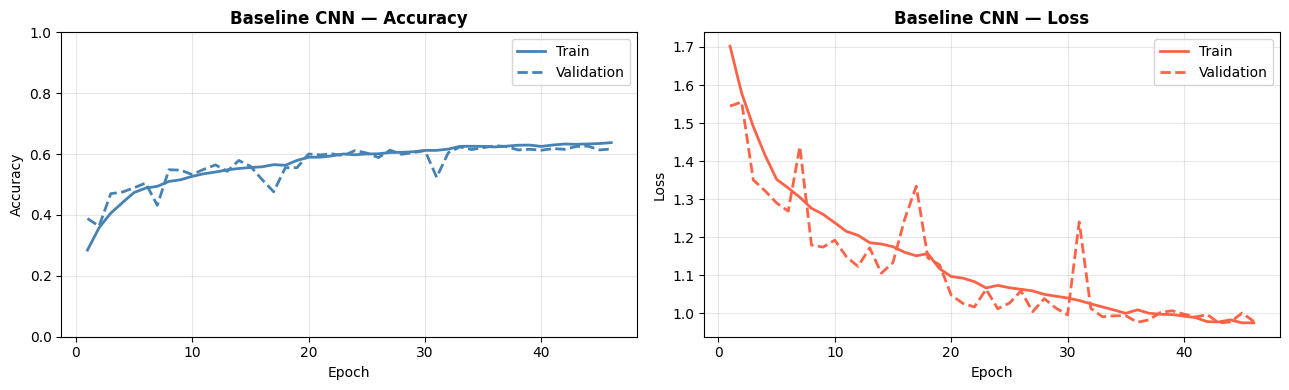

111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step

Baseline CNN — Test Accuracy: 62.94%
              precision    recall  f1-score   support

       angry      0.519     0.619     0.565       958
        fear      0.545     0.295     0.383      1024
       happy      0.886     0.795     0.838      1774
     neutral      0.517     0.701     0.595      1233
         sad      0.510     0.486     0.498      1247
    surprise      0.731     0.809     0.768       831

    accuracy                          0.629      7067
   macro avg      0.618     0.617     0.608      7067
weighted avg      0.638     0.629     0.624      7067



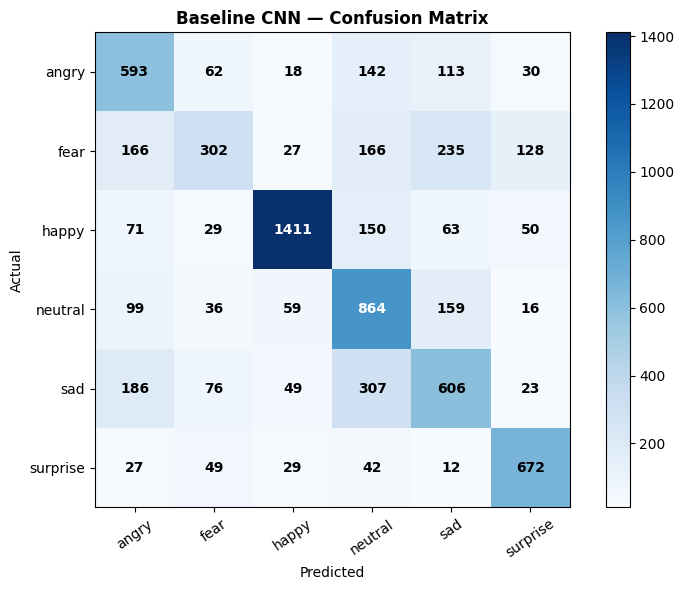

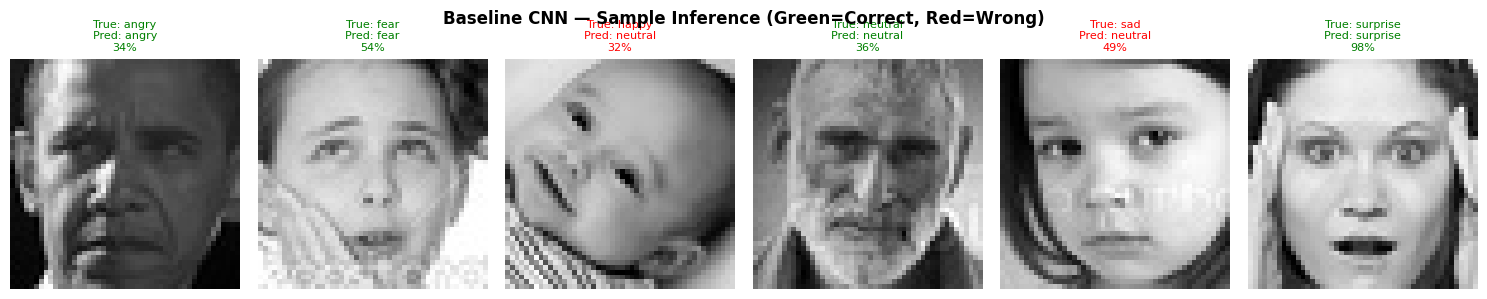

In [ ]:

plot_history(baseline_history, 'Baseline CNN', color='steelblue')
b_preds, b_true, baseline_acc = evaluate_model(baseline_model, test_gen, 'Baseline CNN')
sample_inference(baseline_model, test_dir, classes, 'Baseline CNN', 'grayscale', (48, 48))

In [ ]:
def build_deeper_model():
    model = Sequential([
        # ── Block 1: 32 filters
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),

        # ── Block 2: 64 filters
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),

        # ── Block 3+4: 128 filters (two convs, one pool)
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        # ── Block 5+6: 256 filters (two convs, one pool)
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        # ── FCN — 3 layers, aggressive regularisation
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),

        # ── Output
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper_model()
deeper_model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
deeper_model.summary()
print(f"\nBaseline params : {baseline_model.count_params():,}")
print(f"Deeper   params : {deeper_model.count_params():,}")

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       590,08

 Total params: 1,762,118 (6.72 MB)

 Trainable params: 1,759,622 (6.71 MB)

 Non-trainable params: 2,496 (9.75 KB)


Baseline params : 1,316,550
Deeper   params : 1,762,118


In [ ]:
print("Training Deeper CNN with Adam...")
t0 = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=4, patience_es=10),
    verbose         = 1
)

deeper_time = (time.time() - t0) / 60
print(f"\nDeeper (Adam) Training Time: {deeper_time:.1f} min")
print(f"Epochs completed: {len(deeper_history.history['accuracy'])}")

Training Deeper CNN with Adam...
Epoch 1/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accuracy: 0.1941 - loss: 2.0399 - val_accuracy: 0.2561 - val_loss: 1.8481 - learning_rate: 5.0000e-04
Epoch 2/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.2146 - loss: 1.8862 - val_accuracy: 0.2570 - val_loss: 1.8060 - learning_rate: 5.0000e-04
Epoch 3/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.2337 - loss: 1.8374 - val_accuracy: 0.2980 - val_loss: 1.7362 - learning_rate: 5.0000e-04
Epoch 4/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.2812 - loss: 1.7664 - val_accuracy: 0.3442 - val_loss: 1.6789 - learning_rate: 5.0000e-04
Epoch 5/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.3288 - loss: 1.6943 - val_accuracy: 0.3329 - val_loss: 1.7001 - learning_rate: 5.0000e-04
Epoch 6/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.3664 - loss: 1.6344 - val_accuracy: 0.4224 - val_loss: 1.5267 - learning_rate: 5.0000e-04
Epoch 7/60
354/354 

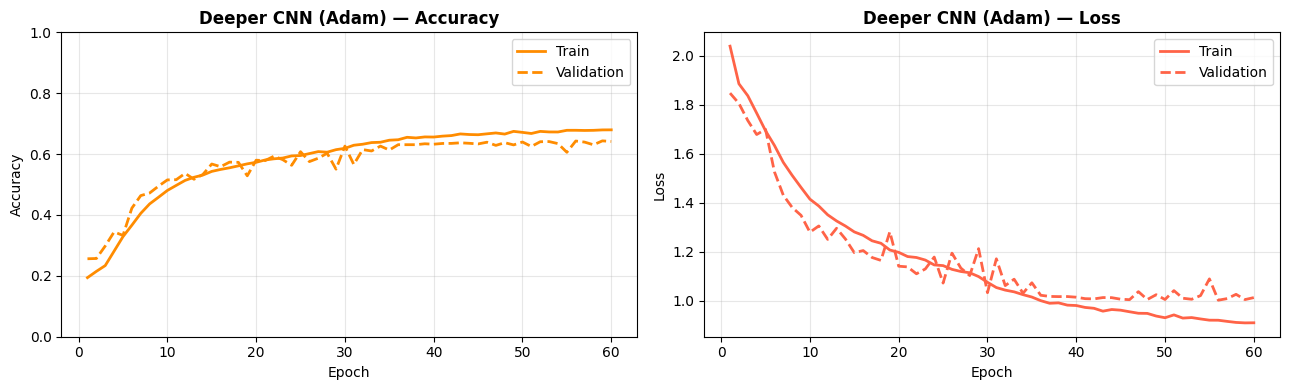

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step

Deeper CNN (Adam) — Test Accuracy: 64.72%
              precision    recall  f1-score   support

       angry      0.526     0.649     0.581       958
        fear      0.546     0.391     0.455      1024
       happy      0.904     0.814     0.856      1774
     neutral      0.532     0.720     0.612      1233
         sad      0.586     0.427     0.494      1247
    surprise      0.706     0.828     0.762       831

    accuracy                          0.647      7067
   macro avg      0.633     0.638     0.627      7067
weighted avg      0.656     0.647     0.643      7067



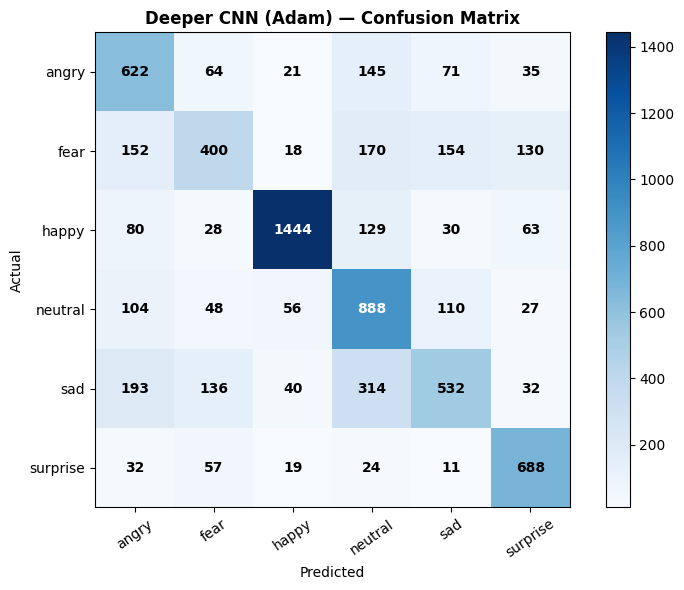

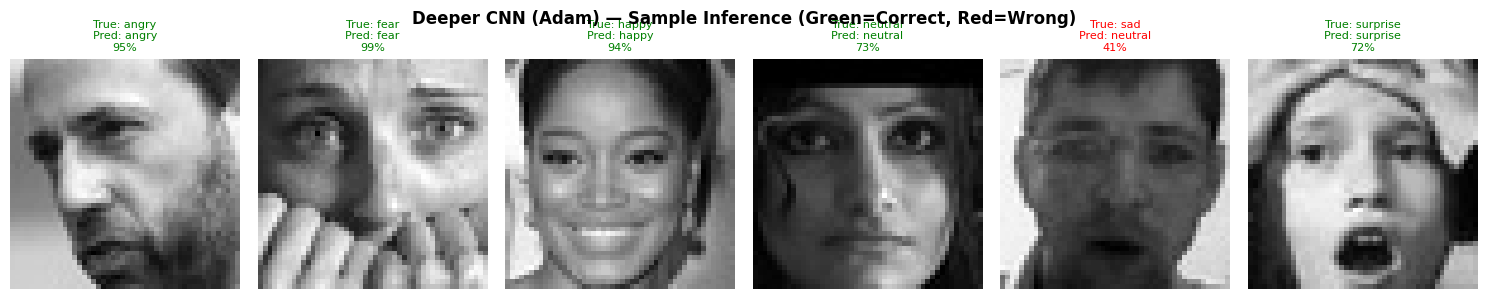

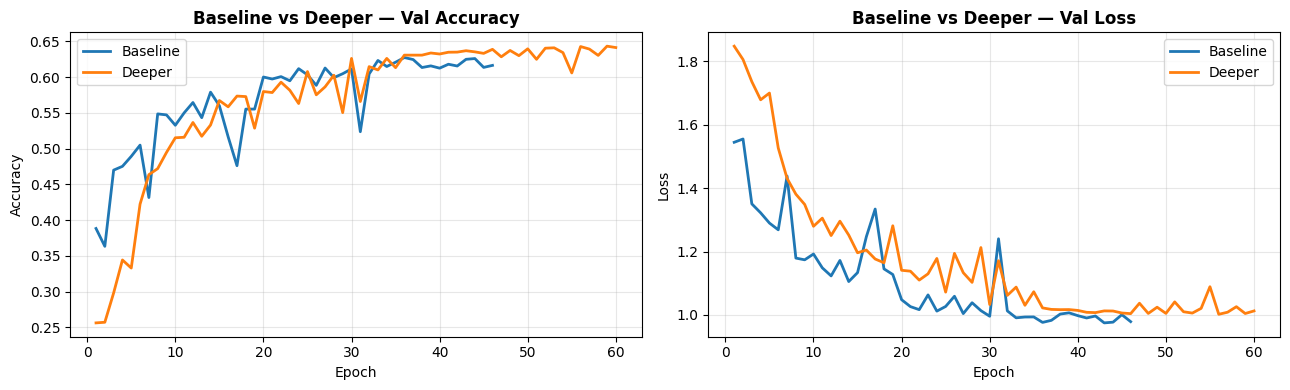

In [ ]:
plot_history(deeper_history, 'Deeper CNN (Adam)', color='darkorange')
d_preds, d_true, deeper_acc = evaluate_model(deeper_model, test_gen, 'Deeper CNN (Adam)')
sample_inference(deeper_model, test_dir, classes, 'Deeper CNN (Adam)', 'grayscale', (48, 48))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
e_b = range(1, len(baseline_history.history['val_accuracy']) + 1)
e_d = range(1, len(deeper_history.history['val_accuracy']) + 1)

axes[0].plot(e_b, baseline_history.history['val_accuracy'], label='Baseline', lw=2)
axes[0].plot(e_d, deeper_history.history['val_accuracy'],  label='Deeper',   lw=2)
axes[0].set_title('Baseline vs Deeper — Val Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(e_b, baseline_history.history['val_loss'], label='Baseline', lw=2)
axes[1].plot(e_d, deeper_history.history['val_loss'],  label='Deeper',   lw=2)
axes[1].set_title('Baseline vs Deeper — Val Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
sgd_model = build_deeper_model()
sgd_model._name = 'Deeper_CNN_SGD'
sgd_model.compile(
    optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("SGD model (Nesterov momentum) compiled")

t0 = time.time()
sgd_history = sgd_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=5, patience_es=12),
    verbose         = 1
)
sgd_time = (time.time() - t0) / 60
print(f"\nSGD Training Time: {sgd_time:.1f} min")

SGD model (Nesterov momentum) compiled
Epoch 1/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - accuracy: 0.2019 - loss: 1.9090 - val_accuracy: 0.1829 - val_loss: 1.8398 - learning_rate: 0.0100
Epoch 2/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.2207 - loss: 1.8324 - val_accuracy: 0.2510 - val_loss: 1.8035 - learning_rate: 0.0100
Epoch 3/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.2457 - loss: 1.8012 - val_accuracy: 0.2306 - val_loss: 1.8685 - learning_rate: 0.0100
Epoch 4/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.2792 - loss: 1.7511 - val_accuracy: 0.1162 - val_loss: 2.9052 - learning_rate: 0.0100
Epoch 5/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.3200 - loss: 1.6935 - val_accuracy: 0.3790 - val_loss: 1.6057 - learning_rate: 0.0100
Epoch 6/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.3488 - loss: 1.6447 - val_accuracy: 0.4156 - val_loss: 1.5321 - learning_rate: 0.0100
Epoch 7/60
354/354 ━━━━━━━━━━━━━━━━━━

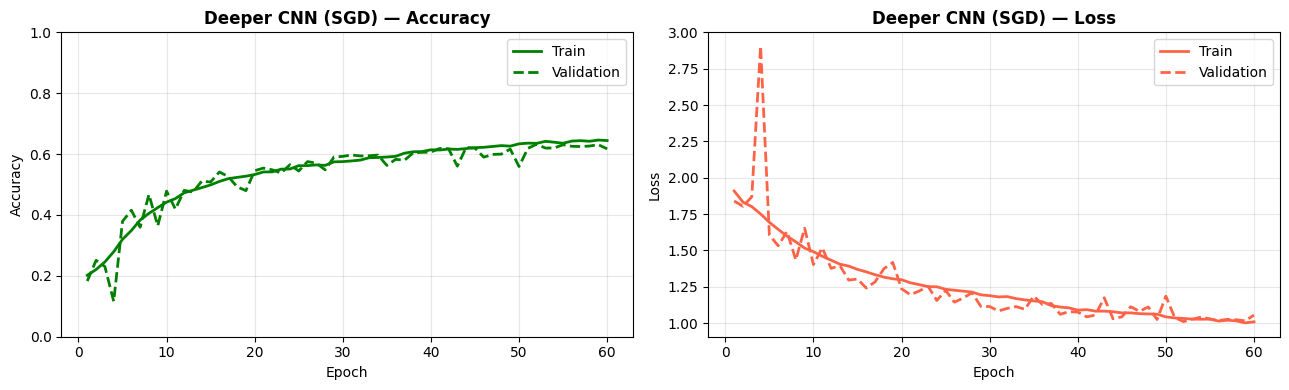

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step

Deeper CNN (SGD) — Test Accuracy: 64.61%
              precision    recall  f1-score   support

       angry      0.586     0.590     0.588       958
        fear      0.590     0.305     0.402      1024
       happy      0.861     0.840     0.851      1774
     neutral      0.527     0.713     0.606      1233
         sad      0.521     0.513     0.517      1247
    surprise      0.717     0.817     0.764       831

    accuracy                          0.646      7067
   macro avg      0.634     0.630     0.621      7067
weighted avg      0.649     0.646     0.638      7067



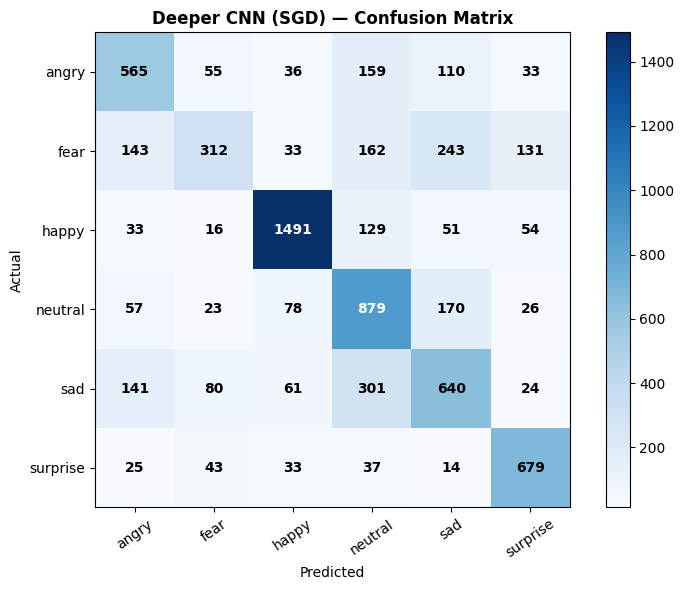

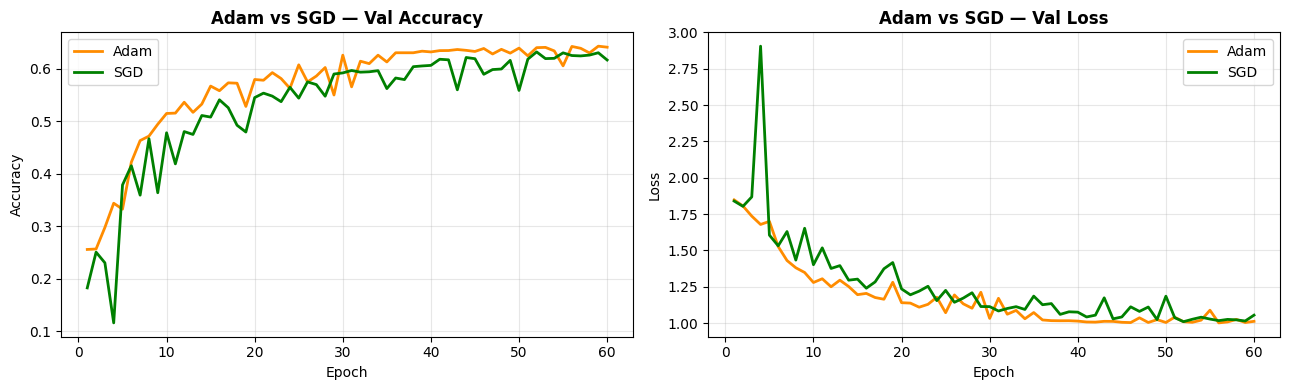

In [ ]:
plot_history(sgd_history, 'Deeper CNN (SGD)', color='green')
sgd_preds, sgd_true, sgd_acc = evaluate_model(sgd_model, test_gen, 'Deeper CNN (SGD)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
e_d = range(1, len(deeper_history.history['val_accuracy']) + 1)
e_s = range(1, len(sgd_history.history['val_accuracy'])   + 1)

axes[0].plot(e_d, deeper_history.history['val_accuracy'], label='Adam', lw=2, color='darkorange')
axes[0].plot(e_s, sgd_history.history['val_accuracy'],   label='SGD',  lw=2, color='green')
axes[0].set_title('Adam vs SGD — Val Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(e_d, deeper_history.history['val_loss'], label='Adam', lw=2, color='darkorange')
axes[1].plot(e_s, sgd_history.history['val_loss'],   label='SGD',  lw=2, color='green')
axes[1].set_title('Adam vs SGD — Val Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def build_ablation_no_dropout():
    model = Sequential([
        # Block 1
        Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        BatchNormalization(), MaxPooling2D(2,2),
        # NO Dropout
        # Block 2
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        # NO Dropout
        # Block 3+4
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        # NO Dropout
        # Block 5+6
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        # NO Dropout
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        # NO Dropout
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Ablation_NoDropout')
    return model

ablation_model = build_ablation_no_dropout()
ablation_model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("Ablation model (No Dropout) compiled")

t0 = time.time()
ablation_history = ablation_model.fit(
    train_gen,
    epochs          = 40,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=4, patience_es=8),
    verbose         = 1
)
ablation_time = (time.time() - t0) / 60
print(f"\nAblation Training Time: {ablation_time:.1f} min")

Ablation model (No Dropout) compiled
Epoch 1/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.2734 - loss: 1.8084 - val_accuracy: 0.2320 - val_loss: 1.9469 - learning_rate: 5.0000e-04
Epoch 2/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.3904 - loss: 1.5978 - val_accuracy: 0.3594 - val_loss: 1.8039 - learning_rate: 5.0000e-04
Epoch 3/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.4590 - loss: 1.4475 - val_accuracy: 0.3580 - val_loss: 1.6929 - learning_rate: 5.0000e-04
Epoch 4/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.4960 - loss: 1.3688 - val_accuracy: 0.4950 - val_loss: 1.3383 - learning_rate: 5.0000e-04
Epoch 5/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.5341 - loss: 1.2920 - val_accuracy: 0.5410 - val_loss: 1.2847 - learning_rate: 5.0000e-04
Epoch 6/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.5534 - loss: 1.2460 - val_accuracy: 0.4991 - val_loss: 1.3971 - learning_rate: 5.0000e-04
Epoch 7/40
354/

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step

Ablation (No Dropout) — Test Accuracy: 65.49%
              precision    recall  f1-score   support

       angry      0.558     0.632     0.592       958
        fear      0.544     0.433     0.482      1024
       happy      0.893     0.816     0.852      1774
     neutral      0.552     0.689     0.613      1233
         sad      0.554     0.488     0.519      1247
    surprise      0.744     0.811     0.776       831

    accuracy                          0.655      7067
   macro avg      0.641     0.645     0.639      7067
weighted avg      0.660     0.655     0.654      7067



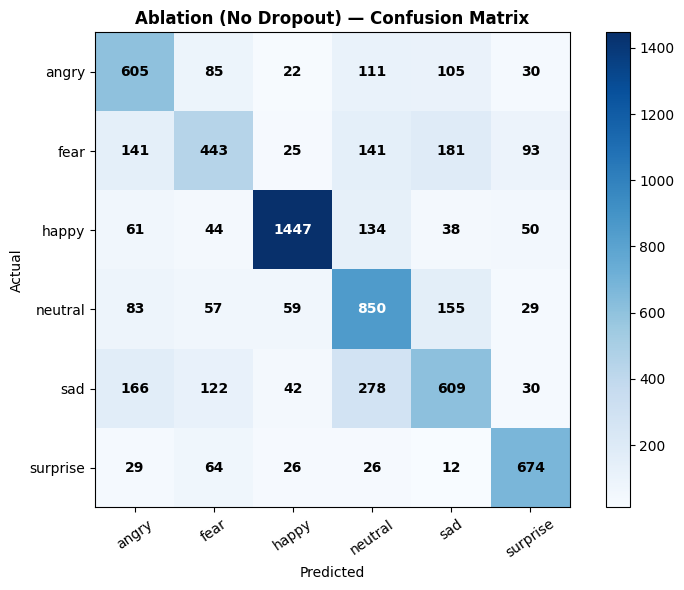

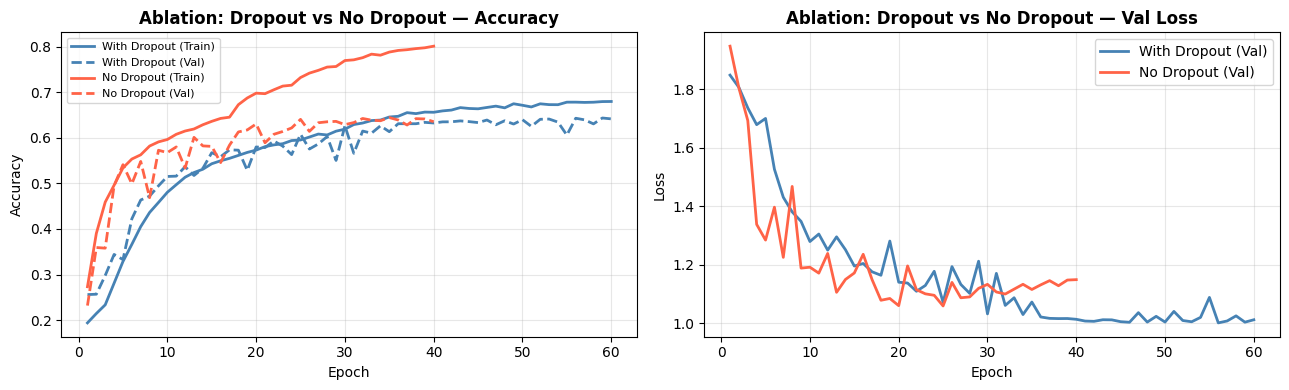


Ablation Finding:
  Train-Val gap WITH Dropout   : 3.6%
  Train-Val gap WITHOUT Dropout: 15.7%
  → Larger gap without dropout confirms overfitting when dropout is removed.


In [ ]:
ab_preds, ab_true, ablation_acc = evaluate_model(ablation_model, test_gen, 'Ablation (No Dropout)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
e_d  = range(1, len(deeper_history.history['val_accuracy'])   + 1)
e_ab = range(1, len(ablation_history.history['val_accuracy']) + 1)

axes[0].plot(e_d,  deeper_history.history['train_accuracy']   if 'train_accuracy' in deeper_history.history
             else deeper_history.history['accuracy'], label='With Dropout (Train)', lw=2, ls='-',  color='steelblue')
axes[0].plot(e_d,  deeper_history.history['val_accuracy'],   label='With Dropout (Val)',   lw=2, ls='--', color='steelblue')
axes[0].plot(e_ab, ablation_history.history['accuracy'],     label='No Dropout (Train)',  lw=2, ls='-',  color='tomato')
axes[0].plot(e_ab, ablation_history.history['val_accuracy'], label='No Dropout (Val)',    lw=2, ls='--', color='tomato')
axes[0].set_title('Ablation: Dropout vs No Dropout — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(e_d,  deeper_history.history['val_loss'],   label='With Dropout (Val)',  lw=2, color='steelblue')
axes[1].plot(e_ab, ablation_history.history['val_loss'], label='No Dropout (Val)',    lw=2, color='tomato')
axes[1].set_title('Ablation: Dropout vs No Dropout — Val Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAblation Finding:")
gap_with    = max(deeper_history.history['accuracy'])   - max(deeper_history.history['val_accuracy'])
gap_without = max(ablation_history.history['accuracy']) - max(ablation_history.history['val_accuracy'])
print(f"  Train-Val gap WITH Dropout   : {gap_with*100:.1f}%")
print(f"  Train-Val gap WITHOUT Dropout: {gap_without*100:.1f}%")
print("  → Larger gap without dropout confirms overfitting when dropout is removed.")

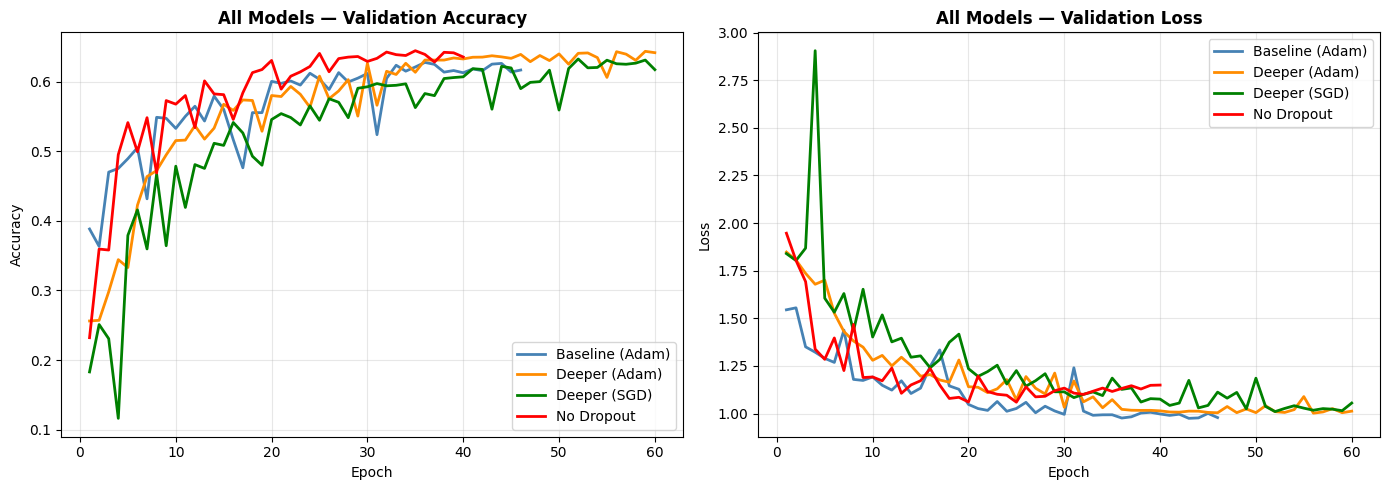

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_histories = [
    (baseline_history, 'Baseline (Adam)', 'steelblue'),
    (deeper_history,   'Deeper (Adam)',   'darkorange'),
    (sgd_history,      'Deeper (SGD)',    'green'),
    (ablation_history, 'No Dropout',      'red'),
]
for hist, label, color in model_histories:
    e = range(1, len(hist.history['val_accuracy']) + 1)
    axes[0].plot(e, hist.history['val_accuracy'], label=label, lw=2, color=color)
    axes[1].plot(e, hist.history['val_loss'],     label=label, lw=2, color=color)

axes[0].set_title('All Models — Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('All Models — Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 20: Part A Summary Table ─────────────────────────────────────────────

summary = pd.DataFrame({
    'Model'         : ['Baseline (Adam)', 'Deeper (Adam)', 'Deeper (SGD)', 'Ablation (No Dropout)'],
    'Params'        : [f"{baseline_model.count_params():,}",
                       f"{deeper_model.count_params():,}",
                       f"{sgd_model.count_params():,}",
                       f"{ablation_model.count_params():,}"],
    'Epochs'        : [len(baseline_history.history['accuracy']),
                       len(deeper_history.history['accuracy']),
                       len(sgd_history.history['accuracy']),
                       len(ablation_history.history['accuracy'])],
    'Train Time'    : [f'{baseline_time:.1f}m', f'{deeper_time:.1f}m',
                       f'{sgd_time:.1f}m',      f'{ablation_time:.1f}m'],
    'Best Val Acc'  : [f"{max(baseline_history.history['val_accuracy'])*100:.1f}%",
                       f"{max(deeper_history.history['val_accuracy'])*100:.1f}%",
                       f"{max(sgd_history.history['val_accuracy'])*100:.1f}%",
                       f"{max(ablation_history.history['val_accuracy'])*100:.1f}%"],
    'Test Accuracy' : [f'{baseline_acc:.1f}%', f'{deeper_acc:.1f}%',
                       f'{sgd_acc:.1f}%',      f'{ablation_acc:.1f}%'],
})
print("\n" + "=" * 75)
print("PART A — COMPLETE MODEL COMPARISON")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)
print("Hardware: Google Colab T4 GPU")


PART A — COMPLETE MODEL COMPARISON
                Model    Params  Epochs Train Time Best Val Acc Test Accuracy
      Baseline (Adam) 1,316,550      46      17.2m        62.8%         62.9%
        Deeper (Adam) 1,762,118      60      23.5m        64.3%         64.7%
         Deeper (SGD) 1,762,118      60      22.6m        63.2%         64.6%
Ablation (No Dropout) 1,762,118      40      15.5m        64.4%         65.5%
Hardware: Google Colab T4 GPU


In [ ]:
TL_IMG_SIZE = (96, 96)
TL_BATCH    = 64


tl_train_datagen = ImageDataGenerator(
    rescale=1./127.5,
    preprocessing_function=lambda x: x - 1.0,
    validation_split=0.2,
    rotation_range=8, zoom_range=0.08,
    width_shift_range=0.08, height_shift_range=0.08,
    horizontal_flip=True
)
tl_val_datagen  = ImageDataGenerator(
    rescale=1./127.5,
    preprocessing_function=lambda x: x - 1.0,
    validation_split=0.2
)
tl_test_datagen = ImageDataGenerator(
    rescale=1./127.5,
    preprocessing_function=lambda x: x - 1.0
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    train_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', classes=classes,
    color_mode='rgb', subset='training', seed=SEED
)
tl_val_gen = tl_val_datagen.flow_from_directory(
    train_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', classes=classes,
    color_mode='rgb', subset='validation', seed=SEED
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    test_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', classes=classes,
    color_mode='rgb', shuffle=False
)

print(f"Transfer Learning generators ready at {TL_IMG_SIZE} RGB")
print(f"Input range: [-1, 1] (correct for MobileNetV2)")
print(f"Train: {tl_train_gen.samples} | Val: {tl_val_gen.samples} | Test: {tl_test_gen.samples}")

Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Transfer Learning generators ready at (96, 96) RGB
Input range: [-1, 1] (correct for MobileNetV2)
Train: 22619 | Val: 5654 | Test: 7067


In [ ]:
base_model = MobileNetV2(
    input_shape  = (96, 96, 3),
    include_top  = False,
    weights      = 'imagenet'
)

base_model.trainable = False

inputs = Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs, outputs, name='MobileNetV2_FER')

tl_model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

trainable = sum(w.numpy().size for w in tl_model.trainable_weights)
total     = tl_model.count_params()
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,} (head only)")
print(f"Frozen params   : {total - trainable:,} (MobileNetV2 base)")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params    : 2,621,126
Trainable params: 362,374 (head only)
Frozen params   : 2,258,752 (MobileNetV2 base)


Phase 1: Feature Extraction (base frozen)...
Epoch 1/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 121s 285ms/step - accuracy: 0.2460 - loss: 2.3272 - val_accuracy: 0.3329 - val_loss: 1.7803 - learning_rate: 1.0000e-04
Epoch 2/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 70s 198ms/step - accuracy: 0.3085 - loss: 2.0108 - val_accuracy: 0.3592 - val_loss: 1.6985 - learning_rate: 1.0000e-04
Epoch 3/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 70s 199ms/step - accuracy: 0.3396 - loss: 1.8864 - val_accuracy: 0.3813 - val_loss: 1.6256 - learning_rate: 1.0000e-04
Epoch 4/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 70s 199ms/step - accuracy: 0.3553 - loss: 1.7943 - val_accuracy: 0.3960 - val_loss: 1.5906 - learning_rate: 1.0000e-04
Epoch 5/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 72s 202ms/step - accuracy: 0.3594 - loss: 1.7508 - val_accuracy: 0.3926 - val_loss: 1.5832 - learning_rate: 1.0000e-04
Epoch 6/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 72s 204ms/step - accuracy: 0.3731 - loss: 1.7076 - val_accuracy: 0.4093 - val_loss: 1.5513 - learning_rate: 1.0000e-04


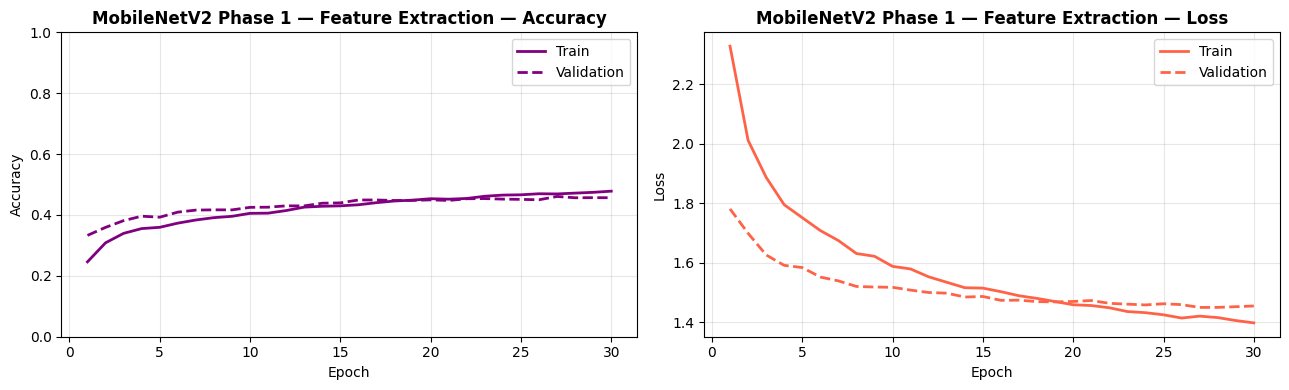

In [ ]:
print("Phase 1: Feature Extraction (base frozen)...")
t0 = time.time()

tl_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=tl_train_gen.classes
)
tl_cw = dict(enumerate(tl_class_weights))

history_p1 = tl_model.fit(
    tl_train_gen,
    epochs          = 30,
    validation_data = tl_val_gen,
    class_weight    = tl_cw,
    callbacks       = get_callbacks(patience_lr=5, patience_es=12),
    verbose         = 1
)
p1_time = (time.time() - t0) / 60
print(f"\nPhase 1 Time: {p1_time:.1f} min")
plot_history(history_p1, 'MobileNetV2 Phase 1 — Feature Extraction', color='purple')

Fine-tuning: 1,888,774 trainable params (top 30 layers + head)
Epoch 1/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 109s 253ms/step - accuracy: 0.4172 - loss: 1.5380 - val_accuracy: 0.4602 - val_loss: 1.4844 - learning_rate: 5.0000e-05
Epoch 2/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 69s 194ms/step - accuracy: 0.4707 - loss: 1.4151 - val_accuracy: 0.4712 - val_loss: 1.4263 - learning_rate: 5.0000e-05
Epoch 3/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 69s 196ms/step - accuracy: 0.4963 - loss: 1.3554 - val_accuracy: 0.4894 - val_loss: 1.3805 - learning_rate: 5.0000e-05
Epoch 4/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 76s 216ms/step - accuracy: 0.5194 - loss: 1.3093 - val_accuracy: 0.4947 - val_loss: 1.3587 - learning_rate: 5.0000e-05
Epoch 5/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 73s 205ms/step - accuracy: 0.5353 - loss: 1.2699 - val_accuracy: 0.5032 - val_loss: 1.3312 - learning_rate: 5.0000e-05
Epoch 6/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 71s 200ms/step - accuracy: 0.5553 - loss: 1.2336 - val_accuracy: 0.5117 - val_loss: 1.3244 - learning

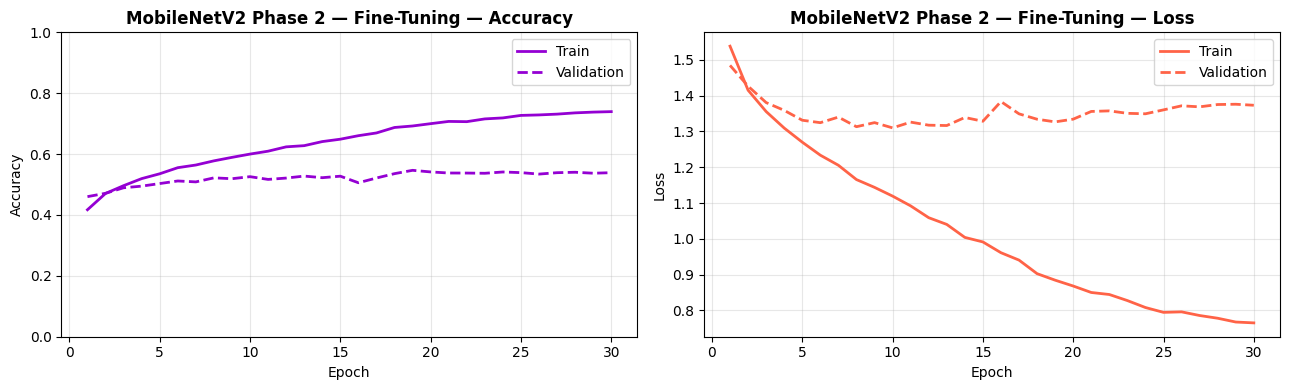

In [ ]:
base_model.trainable = True

fine_tune_from = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

tl_model.compile(
    optimizer = Adam(learning_rate=5e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

ft_trainable = sum(w.numpy().size for w in tl_model.trainable_weights)
print(f"Fine-tuning: {ft_trainable:,} trainable params (top 30 layers + head)")

t0 = time.time()
history_p2 = tl_model.fit(
    tl_train_gen,
    epochs          = 30,
    validation_data = tl_val_gen,
    class_weight    = tl_cw,
    callbacks       = get_callbacks(patience_lr=4, patience_es=12),
    verbose         = 1
)
p2_time = (time.time() - t0) / 60
print(f"\nPhase 2 Fine-Tuning Time: {p2_time:.1f} min")
plot_history(history_p2, 'MobileNetV2 Phase 2 — Fine-Tuning', color='darkviolet')

111/111 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step

MobileNetV2 Transfer Learning — Test Accuracy: 55.47%
              precision    recall  f1-score   support

       angry      0.434     0.463     0.448       958
        fear      0.471     0.325     0.385      1024
       happy      0.748     0.740     0.744      1774
     neutral      0.481     0.500     0.490      1233
         sad      0.452     0.460     0.456      1247
    surprise      0.621     0.770     0.688       831

    accuracy                          0.555      7067
   macro avg      0.534     0.543     0.535      7067
weighted avg      0.552     0.555     0.550      7067



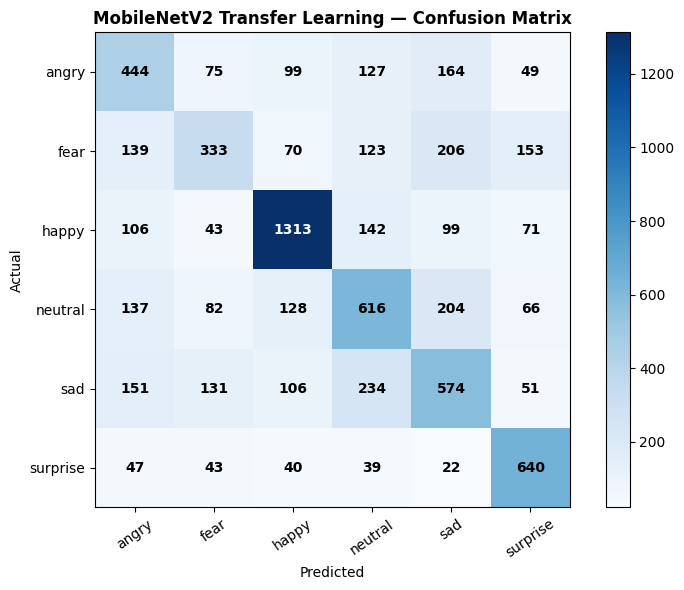

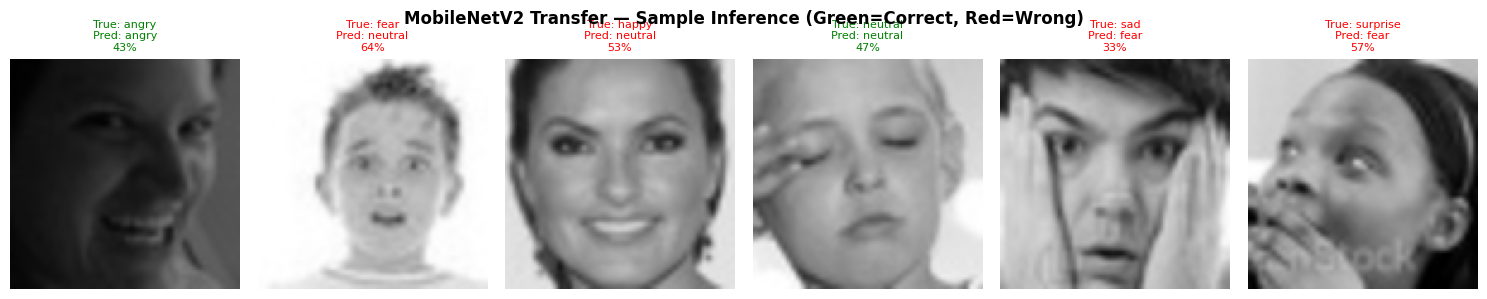

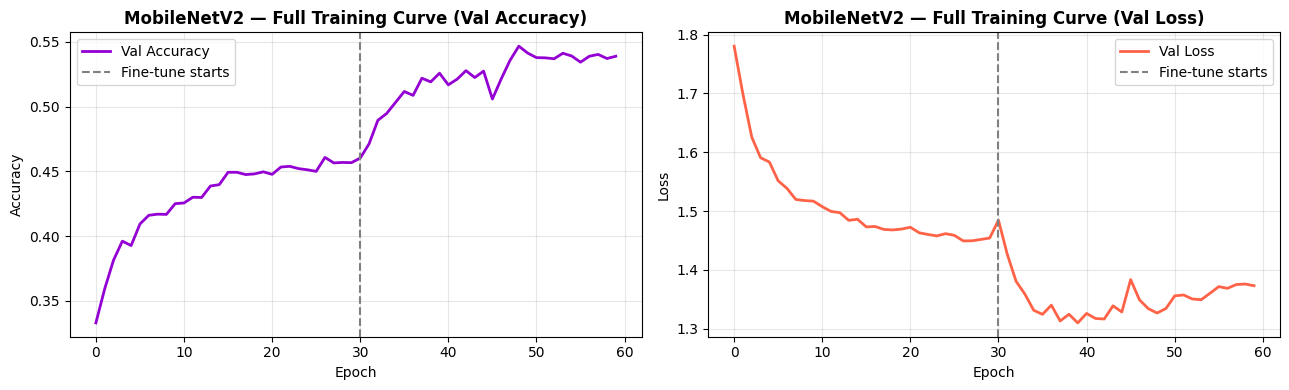

In [ ]:
tl_preds, tl_true, tl_acc = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 Transfer Learning')
sample_inference(tl_model, test_dir, classes, 'MobileNetV2 Transfer', 'rgb', (96, 96))


combined_val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
combined_val_loss = history_p1.history['val_loss']    + history_p2.history['val_loss']
phase1_end = len(history_p1.history['val_accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(combined_val_acc, lw=2, color='darkviolet', label='Val Accuracy')
axes[0].axvline(x=phase1_end, color='gray', ls='--', lw=1.5, label='Fine-tune starts')
axes[0].set_title('MobileNetV2 — Full Training Curve (Val Accuracy)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(combined_val_loss, lw=2, color='tomato', label='Val Loss')
axes[1].axvline(x=phase1_end, color='gray', ls='--', lw=1.5, label='Fine-tune starts')
axes[1].set_title('MobileNetV2 — Full Training Curve (Val Loss)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

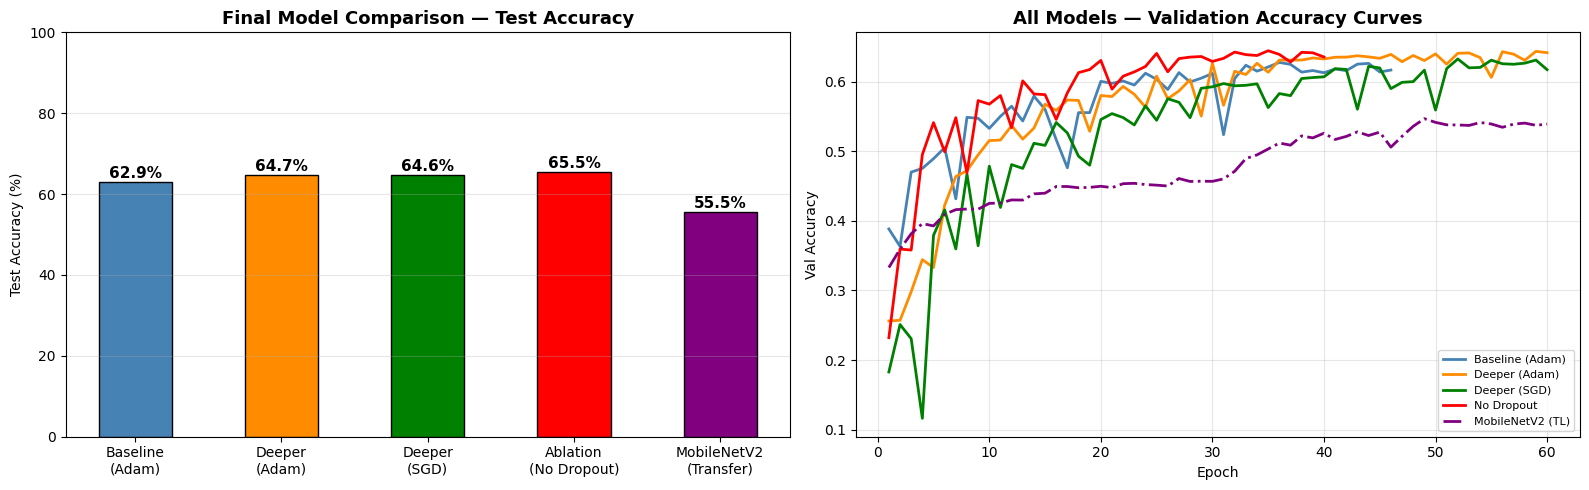


COMPLETE FINAL MODEL COMPARISON
                 Model    Params  Epochs Train Time Test Accuracy
       Baseline (Adam) 1,316,550      46      17.2m         62.9%
         Deeper (Adam) 1,762,118      60      23.5m         64.7%
          Deeper (SGD) 1,762,118      60      22.6m         64.6%
 Ablation (No Dropout) 1,762,118      40      15.5m         65.5%
MobileNetV2 (Transfer) 2,621,126      60      71.7m         55.5%
All training performed on Google Colab with T4 GPU acceleration.


In [ ]:
model_names = ['Baseline\n(Adam)', 'Deeper\n(Adam)', 'Deeper\n(SGD)',
               'Ablation\n(No Dropout)', 'MobileNetV2\n(Transfer)']
accuracies  = [baseline_acc, deeper_acc, sgd_acc, ablation_acc, tl_acc]
colors      = ['steelblue', 'darkorange', 'green', 'red', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar(model_names, accuracies, color=colors, width=0.5, edgecolor='black')
axes[0].set_title('Final Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')


for hist, label, color in model_histories:
    e = range(1, len(hist.history['val_accuracy']) + 1)
    axes[1].plot(e, hist.history['val_accuracy'], label=label, lw=2, color=color)
tl_e = range(1, len(combined_val_acc) + 1)
axes[1].plot(tl_e, combined_val_acc, label='MobileNetV2 (TL)', lw=2, color='purple', ls='-.')
axes[1].set_title('All Models — Validation Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

tl_total_time = p1_time + p2_time
final_summary = pd.DataFrame({
    'Model'         : ['Baseline (Adam)', 'Deeper (Adam)', 'Deeper (SGD)',
                       'Ablation (No Dropout)', 'MobileNetV2 (Transfer)'],
    'Params'        : [f"{baseline_model.count_params():,}",
                       f"{deeper_model.count_params():,}",
                       f"{sgd_model.count_params():,}",
                       f"{ablation_model.count_params():,}",
                       f"{tl_model.count_params():,}"],
    'Epochs'        : [len(baseline_history.history['accuracy']),
                       len(deeper_history.history['accuracy']),
                       len(sgd_history.history['accuracy']),
                       len(ablation_history.history['accuracy']),
                       len(history_p1.history['accuracy']) + len(history_p2.history['accuracy'])],
    'Train Time'    : [f'{baseline_time:.1f}m', f'{deeper_time:.1f}m',
                       f'{sgd_time:.1f}m', f'{ablation_time:.1f}m',
                       f'{tl_total_time:.1f}m'],
    'Test Accuracy' : [f'{baseline_acc:.1f}%', f'{deeper_acc:.1f}%',
                       f'{sgd_acc:.1f}%', f'{ablation_acc:.1f}%',
                       f'{tl_acc:.1f}%'],
})
print("\n" + "=" * 78)
print("COMPLETE FINAL MODEL COMPARISON")
print("=" * 78)
print(final_summary.to_string(index=False))
print("=" * 78)
print("All training performed on Google Colab with T4 GPU acceleration.")